# This notebook is used to create bio-sythesis pipeline for top 20 recomended antiviral molecules using BioPKS

In [1]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
from biopks_pipeline import biopks_pipeline
from DORA_XGB import DORA_XGB
import warnings
warnings.simplefilter('ignore')
from rdkit import Chem
import pygraphviz as pgv
import time

In [3]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
outputDir = os.path.join(resultsDir, 'BioPKS/bacteria/')
os.makedirs(outputDir, exist_ok=True)

Single-SMILES PKS Compatibility Checker

### Experimentally reported structure of `Basidalin`

https://pubs.acs.org/doi/10.1021/acs.joc.6b01255

In [ ]:
Celery job successfully submitted to TridentSynth! Task ID: 833a2940-bb40-46f4-a54a-311b5f4945ae

In [5]:
# Try to read CIF file
#mol = Chem.MolFromPDBFile(dataDir + 'CIF_files/basidalin.cif')  # Sometimes works for CIF files
# or
#mol = Chem.rdmolfiles.MolFromMMCIFFile(dataDir + 'CIF_files/basidalin.cif')  # For mmCIF format

from ase.io import read
from rdkit import Chem
from rdkit.Chem import AllChem

# Read CIF file using ASE
atoms = read(dataDir + 'CIF_files/basidalin.cif')

# Convert ASE atoms to XYZ format
xyz_string = atoms.get_chemical_formula() + '\n\n'
for atom, pos in zip(atoms.get_chemical_symbols(), atoms.get_positions()):
    xyz_string += f"{atom} {pos[0]:.6f} {pos[1]:.6f} {pos[2]:.6f}\n"

# Convert XYZ to RDKit molecule
mol = Chem.MolFromXYZBlock(xyz_string)

if mol is not None:
    smiles = Chem.MolToSmiles(mol)
    print(f"SMILES: {smiles}")

### Run BioPKS for `Basidalin`

In [7]:
target_smiles = 'C1=C(/C(=C\C=O)/OC1=O)N'

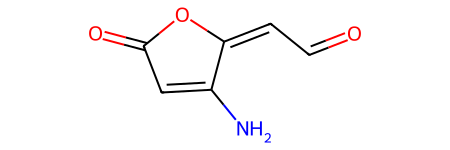

In [8]:
from rdkit import Chem
Chem.MolFromSmiles(target_smiles)

In [14]:
pathway_sequence = ['pks','bio']  # choose between ['pks'] or ['pks','bio']
target_name = 'gluconic_lactone'
pks_release_mechanism = 'thiolysis' # choose from 'cyclization' or 'thiolysis'

Define configuration file path for BioPKS

In [15]:
config_filepath = os.path.join('/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/BioPKS_config_file.json')

we initialize DORA-XGB, a supervised learning classifier that can help predict the feasibility of reactions catalyzed by regular, monofunctional enzymes in Biology.

In [16]:
post_pks_rxn_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat',
                                                     model_type = "spare")

initialize an object of the biopks_pipeline class

In [17]:
biopks_pipeline_object = biopks_pipeline.biopks_pipeline(
                                             pathway_sequence = pathway_sequence,
                                             target_smiles = target_smiles,
                                             target_name = target_name,
                                             feasibility_classifier = post_pks_rxn_model,
                                             pks_release_mechanism = pks_release_mechanism,
                                             config_filepath = config_filepath
                                             )


Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases


begin a combined PKS and post-PKS synthesis with BioPKS Pipeline

In [18]:
### ----- Start synthesis -----
if __name__ == "__main__":
    start_time = time.time()
    biopks_pipeline_object.run_combined_synthesis(max_designs = 4)
    biopks_pipeline_object.save_results_logs()

    print(f"Time: {time.time() - start_time: .2f} s")


Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.6
computing module 2
   testing 600 designs
   best score is 0.7
computing module 3
   testing 600 designs
   best score is 0.6666666666666666

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Hydroxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'loading: False']]

Closest final product is: CC=C(O)C=CC(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Hydroxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'loading: False']] is CC=C(O)C=CC(=O)O.

Moving onto non-PKS modifications...
Job name: gluconic_lactone_PKS0_BIO1
Job type: enzymatic ne

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/BioPKS-Pipeline/biopks_pipeline/../../DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus//gluconic_lactone_PKS_BIO1_config.json'

### Run BioPKS pipeline for all molecules in the dataframe

Step 1: Canonicalizing SMILES strings...
Molecule 1: Canonicalization successful
  Original:  COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3
  Canonical: COCCn1c(N(C)Cc2ccccc2)nc2c1c(=O)[nH]c(=O)n2C
Molecule 2: Canonicalization successful
  Original:  COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O
  Canonical: COCCn1c(N)c(N(Cc2ccccc2)C(C)=O)c(=O)[nH]c1=O
Molecule 3: Canonicalization successful
  Original:  COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C
  Canonical: COCCn1cc(NC(=O)C2C(C=C(C)C)C2(C)C)ccc1=O
Molecule 4: Canonicalization successful
  Original:  COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3
  Canonical: COCCn1c(NN=Cc2ccccc2)nc2c1c(=O)[nH]c(=O)n2C
Molecule 5: Canonicalization successful
  Original:  COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32
  Canonical: COc1ccc(OC)c(C(O)Cn2c(C)nc3ccccc32)c1
Molecule 6: Canonicalization successful
  Original:  CCC=1C=C(CC)N(N1)C2=NC3=C(C(=O)NC(=O)N3C)N2CCOC
  Canonical: CCc1cc(CC)n(-c2nc3c(c(=O)[nH]c(=O)n3C)n2CCOC)n1
Molecule 7: Canonicalizatio

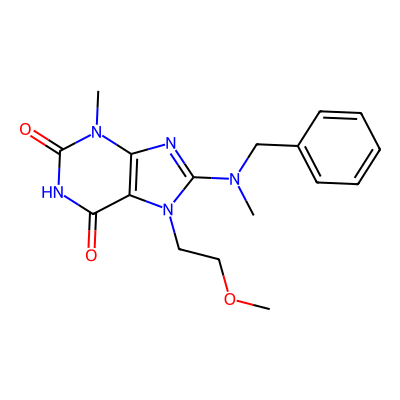

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_1.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.14814814814814814
computing module 2
   testing 600 designs
   best score is 0.13793103448275862

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: CC=C(OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']] is CC=C(OC)C(=O)O.

Moving onto non-PKS modifications...
Job name

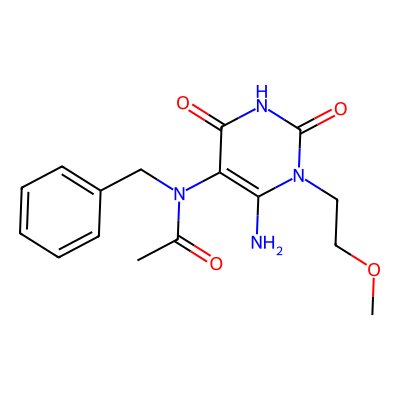

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_2.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.15384615384615385
computing module 2
   testing 600 designs
   best score is 0.14285714285714285

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: CC=C(OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']] is CC=C(OC)C(=O)O.

Moving onto non-PKS modifications...
Job name

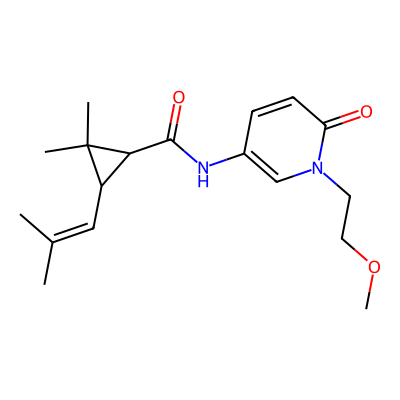

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_3.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.30434782608695654
computing module 2
   testing 600 designs
   best score is 0.375
computing module 3
   testing 600 designs
   best score is 0.34615384615384615

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Allylmalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False'], ["AT{'substrate': 'Methylmalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: C=CC[C@H](C=C(C)C(=O)O)CC

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'l

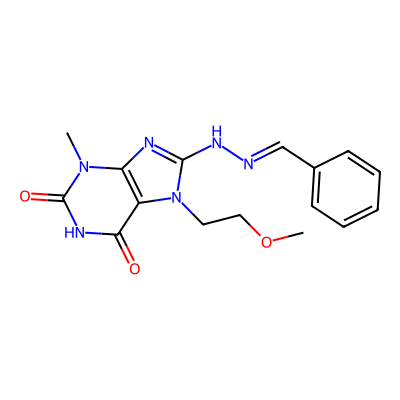

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_4.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.14814814814814814
computing module 2
   testing 600 designs
   best score is 0.13793103448275862

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: CC=C(OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']] is CC=C(OC)C(=O)O.

Moving onto non-PKS modifications...
Job name

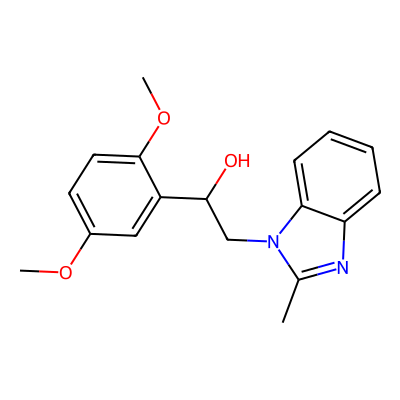

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_5.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.16666666666666666
computing module 2
   testing 600 designs
   best score is 0.15384615384615385

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Hydroxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False']]

Closest final product is: CC[C@H](O)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Hydroxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False']] is CC[C@H](O)C(=O)O.

Moving onto non-PKS modif

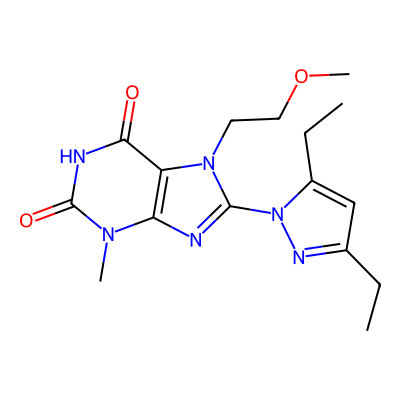

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_6.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.14814814814814814
computing module 2
   testing 600 designs
   best score is 0.13793103448275862

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: CC=C(OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']] is CC=C(OC)C(=O)O.

Moving onto non-PKS modifications...
Job name

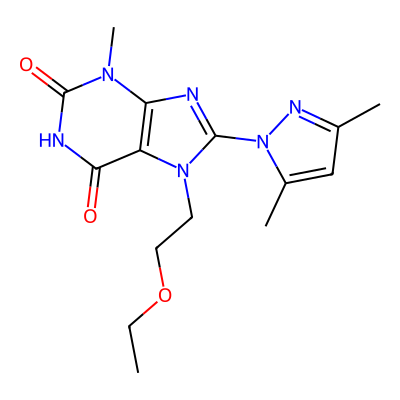

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_7.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.15384615384615385
computing module 2
   testing 600 designs
   best score is 0.14285714285714285

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: CC=C(OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']] is CC=C(OC)C(=O)O.

Moving onto non-PKS modifications...
Job name

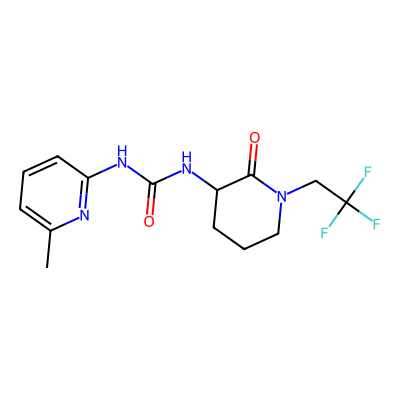

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_8.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.21739130434782608
computing module 2
   testing 600 designs
   best score is 0.24
computing module 3
   testing 600 designs
   best score is 0.2222222222222222

Best PKS design: [["AT{'substrate': 'Methylmalonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'ER{}', 'loading: False'], ["AT{'substrate': 'Malonyl-CoA'}", 'loading: False']]

Closest final product is: CCCCC(=O)CC(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Methylmalonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malo

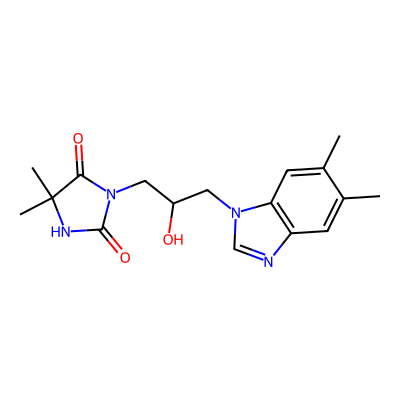

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_9.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.2
computing module 2
   testing 600 designs
   best score is 0.18518518518518517

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methylmalonyl-CoA'}", 'loading: False']]

Closest final product is: CC(=O)[C@H](C)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methylmalonyl-CoA'}", 'loading: False']] is CC(=O)[C@H](C)C(=O)O.

Moving onto non-PKS modifications...
Job name: molecule_9_PKS0_BIO1
Job type: enzymatic network expansion f

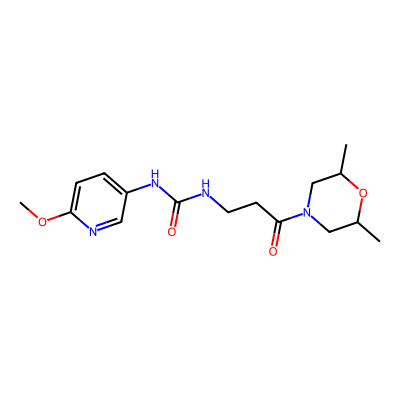

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_10.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.2
computing module 2
   testing 600 designs
   best score is 0.18518518518518517

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False']]

Closest final product is: CC[C@H](OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False']] is CC[C@H](OC)C(=O)O.

Moving onto non-PKS modifications...
J

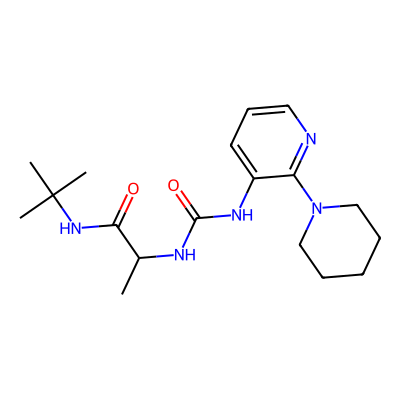

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_11.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.2
computing module 2
   testing 600 designs
   best score is 0.18518518518518517

Best PKS design: [["AT{'substrate': 'Methylmalonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'ER{}', 'loading: False']]

Closest final product is: CCCCC(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Methylmalonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'ER{}', 'loading: False']] is CCCCC(=O)O.

Moving onto non-PKS modifications...
Job name: molecule_

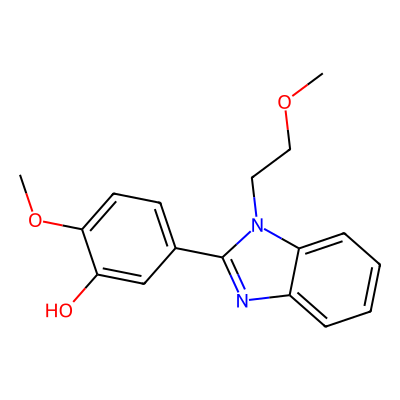

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_12.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.16666666666666666
computing module 2
   testing 600 designs
   best score is 0.15384615384615385

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: CC=C(OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']] is CC=C(OC)C(=O)O.

Moving onto non-PKS modifications...
Job nam

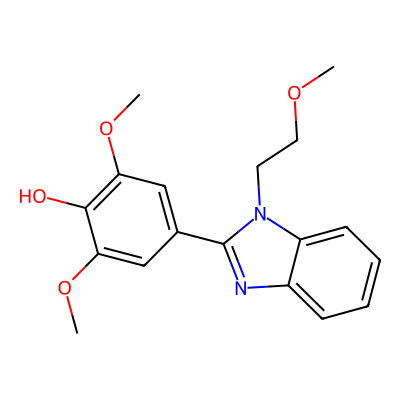

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_13.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.15384615384615385
computing module 2
   testing 600 designs
   best score is 0.14285714285714285

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: CC=C(OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']] is CC=C(OC)C(=O)O.

Moving onto non-PKS modifications...
Job nam

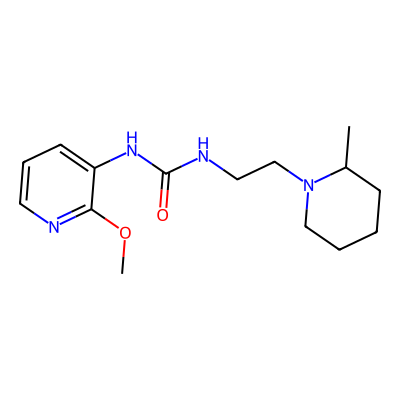

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_14.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.2727272727272727
computing module 2
   testing 600 designs
   best score is 0.2727272727272727

Best PKS design: [["AT{'substrate': 'Allylmalonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'ER{}', 'loading: False']]

Closest final product is: C=CCCCCC(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Allylmalonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'ER{}', 'loading: False']] is C=CCCCCC(=O)O.

Moving onto non-PKS modifications...
J

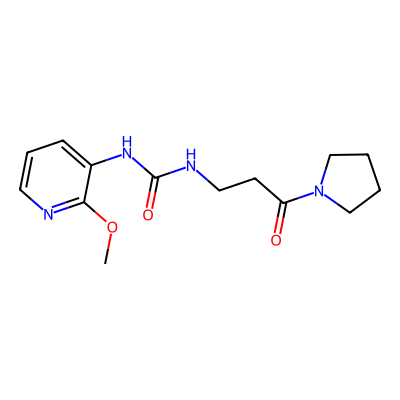

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_15.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.19047619047619047
computing module 2
   testing 600 designs
   best score is 0.17391304347826086

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'ER{}', 'loading: False']]

Closest final product is: CCCC(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'ER{}', 'loading: False']] is CCCC(=O)O.

Moving onto non-PKS modifications...
Job name: molecul

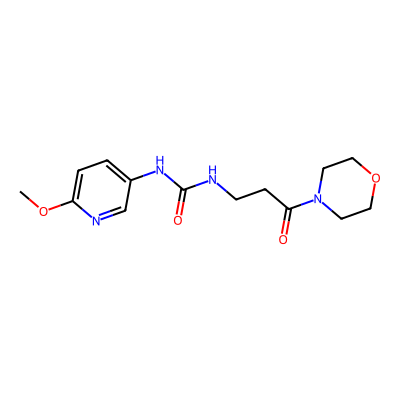

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_16.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.17391304347826086
computing module 2
   testing 600 designs
   best score is 0.16

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", 'loading: False']]

Closest final product is: CC(=O)CC(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", 'loading: False']] is CC(=O)CC(=O)O.

Moving onto non-PKS modifications...
Job name: molecule_16_PKS0_BIO1
Job type: enzymatic network expansion forward
Job started on: 

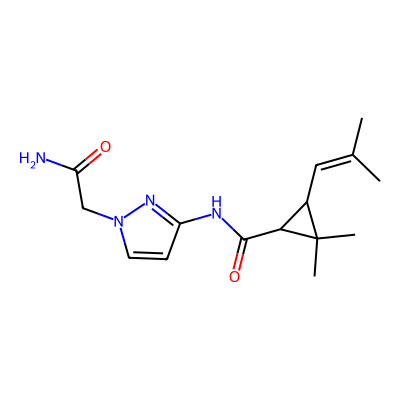

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_17.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.3333333333333333
computing module 2
   testing 600 designs
   best score is 0.4090909090909091
computing module 3
   testing 600 designs
   best score is 0.375

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Allylmalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False'], ["AT{'substrate': 'Methylmalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: C=CC[C@H](C=C(C)C(=O)O)CC

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'lo

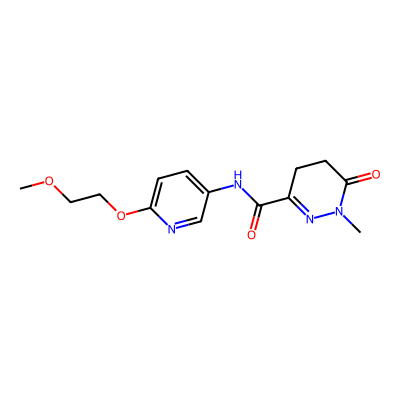

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_18.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.22727272727272727
computing module 2
   testing 600 designs
   best score is 0.25
computing module 3
   testing 600 designs
   best score is 0.2692307692307692
computing module 4
   testing 600 designs
   best score is 0.25

Best PKS design: [["AT{'substrate': 'Methylmalonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", 'loading: False'], ["AT{'substrate': 'Malonyl-CoA'}", "KR{'type': 'B'}", 'DH{}', 'ER{}', 'loading: False'], ["AT{'substrate': 'Malonyl-CoA'}", 'loading: False']]

Closest final product is: CCC(=O)CCCC(=O)CC(=O)O

Finished PKS synthesis: closest product 

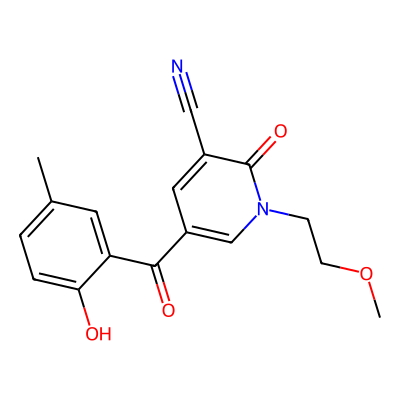

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_19.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.16666666666666666
computing module 2
   testing 600 designs
   best score is 0.15384615384615385

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", 'loading: False']]

Closest final product is: CC(=O)CC(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Malonyl-CoA'}", 'loading: False']] is CC(=O)CC(=O)O.

Moving onto non-PKS modifications...
Job name: molecule_19_PKS0_BIO1
Job type: enzymatic network expansion forward
J

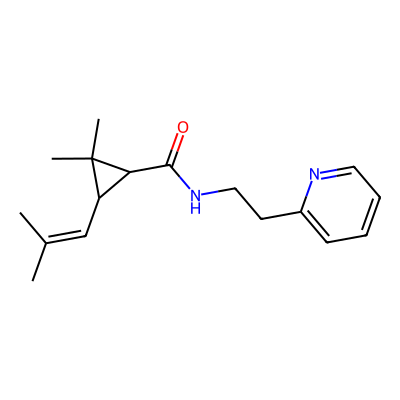

Structure saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/molecule_structures/molecule_20.png

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.35
computing module 2
   testing 600 designs
   best score is 0.42857142857142855
computing module 3
   testing 600 designs
   best score is 0.391304347826087

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Allylmalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False'], ["AT{'substrate': 'Methylmalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: C=CC[C@H](C=C(C)C(=O)O)CC

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loa

,index,original_smiles,canonical_smiles,target_name,status,time_seconds,structure_image,output_directory,error
0,0,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3,COCCn1c(N(C)Cc2ccccc2)nc2c1c(=O)[nH]c(=O)n2C,molecule_1,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...
1,1,COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O,COCCn1c(N)c(N(Cc2ccccc2)C(C)=O)c(=O)[nH]c1=O,molecule_2,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...
2,2,COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C,COCCn1cc(NC(=O)C2C(C=C(C)C)C2(C)C)ccc1=O,molecule_3,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...
3,3,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3,COCCn1c(NN=Cc2ccccc2)nc2c1c(=O)[nH]c(=O)n2C,molecule_4,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...
4,4,COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32,COc1ccc(OC)c(C(O)Cn2c(C)nc3ccccc32)c1,molecule_5,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...
5,5,CCC=1C=C(CC)N(N1)C2=NC3=C(C(=O)NC(=O)N3C)N2CCOC,CCc1cc(CC)n(-c2nc3c(c(=O)[nH]c(=O)n3C)n2CCOC)n1,molecule_6,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...
6,6,CCOCCN1C(=NC2=C1C(=O)NC(=O)N2C)N3N=C(C)C=C3C,CCOCCn1c(-n2nc(C)cc2C)nc2c1c(=O)[nH]c(=O)n2C,molecule_7,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...
7,7,CC=1C=CC=C(N1)NC(=O)NC2CCCN(CC(F)(F)F)C2=O,Cc1cccc(NC(=O)NC2CCCN(CC(F)(F)F)C2=O)n1,molecule_8,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...
8,8,CC1=CC=2N=CN(CC(O)CN3C(=O)NC(C)(C)C3=O)C2C=C1C,Cc1cc2ncn(CC(O)CN3C(=O)NC(C)(C)C3=O)c2cc1C,molecule_9,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...
9,9,COC=1C=CC(=CN1)NC(=O)NCCC(=O)N2CC(C)OC(C)C2,COc1ccc(NC(=O)NCCC(=O)N2CC(C)OC(C)C2)cn1,molecule_10,Failed,None,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,[Errno 2] No such file or directory: '/mnt/dat...


In [86]:
from rdkit.Chem import Draw

# process all molecules
smilesDF = EnamineAntiviralsData_top20.copy()

# Function to canonicalize SMILES
def canonicalizeSmiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, False, "Invalid SMILES: Could not parse molecule"
        
        canonicalSmiles = Chem.MolToSmiles(mol, canonical=True)
        return canonicalSmiles, True, None
    except Exception as e:
        return None, False, str(e)

# Canonicalize all SMILES first
print("Step 1: Canonicalizing SMILES strings...")
print("=" * 60)

canonicalizationResults = []
for idx, row in smilesDF.iterrows():
    originalSmiles = row['SMILES']
    canonicalSmiles, isSuccess, errorMessage = canonicalizeSmiles(originalSmiles)
    
    canonicalizationResults.append({
        'index': idx,
        'original_smiles': originalSmiles,
        'canonical_smiles': canonicalSmiles,
        'canonicalization_success': isSuccess,
        'canonicalization_error': errorMessage
    })
    
    if isSuccess:
        print(f"Molecule {idx+1}: Canonicalization successful")
        if originalSmiles != canonicalSmiles:
            print(f"  Original:  {originalSmiles}")
            print(f"  Canonical: {canonicalSmiles}")
    else:
        print(f"Molecule {idx+1}: Canonicalization failed - {errorMessage}")

# Create canonicalization summary
canonicalizationDF = pd.DataFrame(canonicalizationResults)
smilesDF = smilesDF.merge(canonicalizationDF[['index', 'canonical_smiles', 'canonicalization_success']], 
                          left_index=True, right_on='index', how='left')

# Filter only successfully canonicalized molecules
validSmilesDF = smilesDF[smilesDF['canonicalization_success'] == True].copy()
invalidSmilesDF = smilesDF[smilesDF['canonicalization_success'] == False].copy()

print(f"\nCanonicalization Summary:")
print(f"  Total molecules: {len(smilesDF)}")
print(f"  Successfully canonicalized: {len(validSmilesDF)}")
print(f"  Failed canonicalization: {len(invalidSmilesDF)}")
print("=" * 60 + "\n")

# Save canonicalization results
canonicalizationSummaryPath = os.path.join(outputDir, 'canonicalization_summary.csv')
canonicalizationDF.to_csv(canonicalizationSummaryPath, index=False)
print(f"Canonicalization summary saved to: {canonicalizationSummaryPath}\n")

# Store results
resultsSummary = []

# Parameters (same for all runs)
pathwaySequence = ['pks','bio']
pksReleaseMechanism = 'thiolysis'
configFilePath = os.path.join(
    '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/BioPKS_config_file.json'
)

# Create organized directory structure in outputDir
os.makedirs(outputDir, exist_ok=True)

# Create subdirectories for different output types
imagesDir = os.path.join(outputDir, 'molecule_structures')
biopksResultsDir = os.path.join(outputDir, 'biopks_results')
logsDir = os.path.join(outputDir, 'logs')

os.makedirs(imagesDir, exist_ok=True)
os.makedirs(biopksResultsDir, exist_ok=True)
os.makedirs(logsDir, exist_ok=True)

print(f"Output directory: {outputDir}")
print(f"  - Structures: {imagesDir}")
print(f"  - BioPKS results: {biopksResultsDir}")
print(f"  - Logs: {logsDir}")

# Initialize the post-PKS reaction model once (reuse for all)
postPksReactionModel = DORA_XGB.feasibility_classifier(
    cofactor_positioning='add_concat',
    model_type="spare"
)

print("\nStep 2: Processing molecules with BioPKS pipeline...")
print("=" * 60)

# Loop through only valid SMILES
for idx, row in tqdm(validSmilesDF.iterrows(), total=len(validSmilesDF), desc="Processing molecules"):
    
    originalSmiles = row['SMILES']
    canonicalSmiles = row['canonical_smiles']
    
    # Create a unique target name (you can customize this)
    targetName = f"molecule_{idx+1}"
    
    # Create a subdirectory for this molecule's results
    moleculeOutputDir = os.path.join(biopksResultsDir, targetName)
    os.makedirs(moleculeOutputDir, exist_ok=True)
    
    print(f"\n{'-'*60}")
    print(f"Processing {idx+1}/{len(smilesDF)}: {targetName}")
    print(f"Original SMILES:  {originalSmiles}")
    if originalSmiles != canonicalSmiles:
        print(f"Canonical SMILES: {canonicalSmiles}")
    print(f"Output: {moleculeOutputDir}")
    print(f"{'-'*60}")
    
    # Visualize the molecule structure (using canonical SMILES)
    imagePath = None
    try:
        mol = Chem.MolFromSmiles(canonicalSmiles)
        if mol is not None:
            # Display in notebook/console
            moleculeImage = Draw.MolToImage(mol, size=(400, 400))
            
            # Display inline (if in Jupyter/IPython)
            display(moleculeImage)
            
            # Save to file in images directory
            imagePath = os.path.join(imagesDir, f"{targetName}.png")
            moleculeImage.save(imagePath)
            
            # Also save a copy in the molecule's specific output directory
            imagePathCopy = os.path.join(moleculeOutputDir, f"{targetName}_structure.png")
            moleculeImage.save(imagePathCopy)
            
            # Save SMILES information
            smilesInfoPath = os.path.join(moleculeOutputDir, f"{targetName}_smiles.txt")
            with open(smilesInfoPath, 'w') as f:
                f.write(f"Original SMILES:  {originalSmiles}\n")
                f.write(f"Canonical SMILES: {canonicalSmiles}\n")
            
            print(f"Structure saved to: {imagePath}")
        else:
            print(f"Warning: Could not parse canonical SMILES for visualization")
    except Exception as e:
        print(f"Error visualizing molecule: {e}")
    
    # Run BioPKS pipeline with canonical SMILES
    try:
        startTime = time.time()
        
        # Initialize BioPKS pipeline for this molecule with CANONICAL SMILES
        biopksPipelineObject = biopks_pipeline.biopks_pipeline(
            pathway_sequence=pathwaySequence,
            target_smiles=canonicalSmiles,  # Use canonical SMILES
            target_name=targetName,
            feasibility_classifier=postPksReactionModel,
            pks_release_mechanism=pksReleaseMechanism,
            config_filepath=configFilePath,
            # Add output directory if supported by the pipeline
            # output_dir=moleculeOutputDir  # Uncomment if supported
        )
        
        # Change working directory to molecule output directory before saving
        originalDir = os.getcwd()
        os.chdir(moleculeOutputDir)
        
        try:
            # Run synthesis
            biopksPipelineObject.run_combined_synthesis(max_designs=4)
            
            # Save results
            biopksPipelineObject.save_results_logs()
            
        finally:
            # Always return to original directory
            os.chdir(originalDir)
        
        elapsedTime = time.time() - startTime
        
        # Record success
        resultsSummary.append({
            'index': idx,
            'original_smiles': originalSmiles,
            'canonical_smiles': canonicalSmiles,
            'target_name': targetName,
            'status': 'Success',
            'time_seconds': elapsedTime,
            'structure_image': imagePath,
            'output_directory': moleculeOutputDir,
            'error': None
        })
        
        print(f"Status: Completed successfully in {elapsedTime:.2f} seconds")
        
    except Exception as e:
        # Record failure
        errorMessage = str(e)
        resultsSummary.append({
            'index': idx,
            'original_smiles': originalSmiles,
            'canonical_smiles': canonicalSmiles,
            'target_name': targetName,
            'status': 'Failed',
            'time_seconds': None,
            'structure_image': imagePath,
            'output_directory': moleculeOutputDir,
            'error': errorMessage
        })
        
        # Save error log
        errorLogPath = os.path.join(logsDir, f"{targetName}_error.txt")
        with open(errorLogPath, 'w') as f:
            f.write(f"Target: {targetName}\n")
            f.write(f"Original SMILES: {originalSmiles}\n")
            f.write(f"Canonical SMILES: {canonicalSmiles}\n")
            f.write(f"Error: {errorMessage}\n")
        
        print(f"Status: Processing failed")
        print(f"Error: {errorMessage}")
        print(f"Error log saved to: {errorLogPath}")
        
        # Return to original directory in case of error
        try:
            os.chdir(originalDir)
        except:
            pass
        
        continue  # Continue to next molecule

# Add entries for molecules that failed canonicalization
for idx, row in invalidSmilesDF.iterrows():
    targetName = f"molecule_{idx+1}"
    resultsSummary.append({
        'index': idx,
        'original_smiles': row['SMILES'],
        'canonical_smiles': None,
        'target_name': targetName,
        'status': 'Failed - Invalid SMILES',
        'time_seconds': None,
        'structure_image': None,
        'output_directory': None,
        'error': 'SMILES canonicalization failed'
    })

# Create summary dataframe
resultsDF = pd.DataFrame(resultsSummary)

# Save summary
summaryPath = os.path.join(outputDir, 'BioPKS_batch_processing_summary.csv')
resultsDF.to_csv(summaryPath, index=False)

# Save detailed summary with timestamp
timestamp = time.strftime("%Y%m%d_%H%M%S")
detailedSummaryPath = os.path.join(outputDir, f'BioPKS_batch_summary_{timestamp}.csv')
resultsDF.to_csv(detailedSummaryPath, index=False)

# Calculate statistics
totalMolecules = len(smilesDF)
validMolecules = len(validSmilesDF)
invalidSmiles = len(invalidSmilesDF)
successfulMolecules = (resultsDF['status'] == 'Success').sum()
failedMolecules = len(resultsDF[resultsDF['status'].str.startswith('Failed')])
successRate = (successfulMolecules / validMolecules * 100) if validMolecules > 0 else 0

if successfulMolecules > 0:
    averageTime = resultsDF[resultsDF['status'] == 'Success']['time_seconds'].mean()
    totalTime = resultsDF[resultsDF['status'] == 'Success']['time_seconds'].sum()
else:
    averageTime = 0
    totalTime = 0

# Create a processing report
reportPath = os.path.join(outputDir, 'processing_report.txt')
with open(reportPath, 'w') as f:
    f.write("BioPKS BATCH PROCESSING REPORT\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Configuration file: {configFilePath}\n")
    f.write(f"Pathway sequence: {pathwaySequence}\n")
    f.write(f"PKS release mechanism: {pksReleaseMechanism}\n")
    f.write(f"Maximum designs per molecule: 4\n")
    f.write(f"SMILES canonicalization: Enabled\n\n")
    
    f.write("PROCESSING STATISTICS\n")
    f.write("-" * 60 + "\n")
    f.write(f"Total molecules: {totalMolecules}\n")
    f.write(f"Valid SMILES: {validMolecules}\n")
    f.write(f"Invalid SMILES: {invalidSmiles}\n")
    f.write(f"Successful completions: {successfulMolecules}\n")
    f.write(f"Failed completions: {failedMolecules - invalidSmiles}\n")
    f.write(f"Success rate (valid molecules): {successRate:.2f}%\n\n")
    
    if successfulMolecules > 0:
        f.write(f"Average processing time: {averageTime:.2f} seconds\n")
        f.write(f"Total processing time: {totalTime:.2f} seconds\n\n")
    
    f.write("OUTPUT DIRECTORIES\n")
    f.write("-" * 60 + "\n")
    f.write(f"Main output: {outputDir}\n")
    f.write(f"Structures: {imagesDir}\n")
    f.write(f"BioPKS results: {biopksResultsDir}\n")
    f.write(f"Logs: {logsDir}\n\n")
    
    f.write(f"Summary file: {summaryPath}\n")
    f.write(f"Canonicalization summary: {canonicalizationSummaryPath}\n\n")
    
    if invalidSmiles > 0:
        f.write("INVALID SMILES\n")
        f.write("-" * 60 + "\n")
        for _, row in invalidSmilesDF.iterrows():
            targetName = f"molecule_{row.name+1}"
            f.write(f"Molecule: {targetName}\n")
            f.write(f"SMILES: {row['SMILES']}\n\n")
    
    if (resultsDF['status'] == 'Failed').any():
        f.write("FAILED MOLECULES (Processing Errors)\n")
        f.write("-" * 60 + "\n")
        for _, row in resultsDF[resultsDF['status'] == 'Failed'].iterrows():
            f.write(f"Molecule: {row['target_name']}\n")
            f.write(f"Original SMILES: {row['original_smiles']}\n")
            f.write(f"Canonical SMILES: {row['canonical_smiles']}\n")
            f.write(f"Error: {row['error']}\n\n")


print(f"\nProcessing Statistics:")
print(f"  Total molecules: {totalMolecules}")
print(f"  Valid SMILES: {validMolecules}")
print(f"  Invalid SMILES: {invalidSmiles}")
print(f"  Successful: {successfulMolecules}")
print(f"  Failed: {failedMolecules - invalidSmiles}")
print(f"  Success rate: {successRate:.2f}%")

if successfulMolecules > 0:
    print(f"  Average time: {averageTime:.2f} seconds")
    print(f"  Total time: {totalTime:.2f} seconds")

print(f"\nOutput Files:")
print(f"  Summary: {summaryPath}")
print(f"  Canonicalization: {canonicalizationSummaryPath}")
print(f"  Report: {reportPath}")
print(f"  Structures: {imagesDir}/")
print(f"  BioPKS results: {biopksResultsDir}/")
print(f"  Error logs: {logsDir}/")

# Display summary
resultsDF

Retrosynthesis Tools: IBM RXN for Chemistry

In [17]:
# Configuration Parameters
apiKey = 'apk-7a2cc4604d776559c56bf39435eb59e2ffcd2399ede3895eb750d565649d7756'

In [21]:
# IBM RXN for Chemistry - Batch Retrosynthesis Pipeline
# Process all molecules in EnamineAntiviralsData_top20 dataframe

from rxn4chemistry import RXN4ChemistryWrapper
import pandas as pd
import numpy as np
import time
import json
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

try:
    import matplotlib.pyplot as plt
    hasMatplotlib = True
except ImportError:
    hasMatplotlib = False

# ------------------------------------------------------------------
# Configuration Parameters
# ------------------------------------------------------------------
maxRoutesPerMolecule = 5
maxRetrosynthesisSteps = 6
nBeams = 10
fapThreshold = 0.6
aiModel = '12class-tokens-2021-05-14'  # use default or other model as needed

# ------------------------------------------------------------------
# Initialize RXN API Connection
# ------------------------------------------------------------------
print("Initializing IBM RXN for Chemistry API...")

try:
    rxnWrapper = RXN4ChemistryWrapper(api_key=apiKey)
    # For cloud usage this is usually not needed, but harmless:
    rxnWrapper.set_base_url('https://rxn.res.ibm.com')

    projects_response = rxnWrapper.list_all_projects()
    existingProjects = projects_response.get('projects', []) if isinstance(projects_response, dict) else []
    print("API connection successful")
    print(f"Found {len(existingProjects)} existing projects")

except Exception as e:
    print(f"API connection failed: {e}")
    print("\nPlease check:")
    print("1. API key is correctly set")
    print("2. Internet connection is active")
    print("3. Get API key from: https://rxn.res.ibm.com/rxn/user/profile")
    raise

# ------------------------------------------------------------------
# Setup Project — follow docs exactly
# ------------------------------------------------------------------
projectName = 'Enamine_Antivirals_Retrosynthesis'

print(f"\nCreating / selecting project: {projectName}")

# As in docs:
#   rxn.create_project("rxn4chemistry_tour")
#   rxn.set_project(rxn.project_id)
try:
    rxnWrapper.create_project(projectName)
    rxnWrapper.set_project(rxnWrapper.project_id)
    projectId = rxnWrapper.project_id
    print(f"Using project '{projectName}' with ID: {projectId}")
except Exception as e:
    # If project already exists or something odd happens, try to find it
    print(f"create_project raised: {e}")
    print("Trying to find an existing project with the same name...")

    projects = rxnWrapper.list_all_projects()
    projectList = projects.get('projects', []) if isinstance(projects, dict) else []

    projectId = None
    for proj in projectList:
        if proj.get('name') == projectName:
            projectId = proj.get('id') or proj.get('project_id')
            break

    if projectId is None:
        raise RuntimeError(
            f"Could not obtain a valid project id for project '{projectName}'. "
            f"Please create a project in the RXN GUI or check your subscription."
        )

    rxnWrapper.set_project(projectId)
    print(f"Using existing project '{projectName}' with ID: {projectId}")

print("Project ID set successfully\n")

# ------------------------------------------------------------------
# Function to process a single molecule
# ------------------------------------------------------------------
def processSingleMolecule(
    smiles,
    moleculeId,
    apiWrapper,
    maxResults=5,
    maxSteps=6,
    nBeams=10,
    fap=0.6,
    aiModel='12class-tokens-2021-05-14'
):
    """
    Process a single molecule through IBM RXN retrosynthesis.
    Returns: (resultDict, errorMessage)
    """
    try:
        # As in docs:
        # predict_automatic_retrosynthesis_response = rxn.predict_automatic_retrosynthesis(product=smiles)
        rawResponse = apiWrapper.predict_automatic_retrosynthesis(
            product=smiles,
            availability_pricing_threshold=0,
            available_smiles=None,
            exclude_smiles=None,
            exclude_substructures=None,
            exclude_target_molecule=False,
            fap=fap,
            max_steps=maxSteps,
            nbeams=nBeams,
            pruning_steps=2,
            ai_model=aiModel
        )

        if not isinstance(rawResponse, dict):
            return None, f"Unexpected response type for {moleculeId}: {type(rawResponse)}"

        # Doc pattern: predict_automatic_retrosynthesis_results = rxn.get_predict_automatic_retrosynthesis_results(
        #     predict_automatic_retrosynthesis_response['prediction_id']
        # )
        if 'prediction_id' not in rawResponse:
            msg = rawResponse.get('message') or rawResponse.get('status') or "No 'prediction_id' in response."
            return None, (
                f"IBM RXN did not return a prediction_id for {moleculeId}. "
                f"Message: {msg}. Raw response: {rawResponse}"
            )

        predictionId = rawResponse['prediction_id']

        # Poll for results until status == 'SUCCESS', following docs
        retries = 0
        maxRetries = 60   # 60 * 5s = 5 minutes total

        while retries < maxRetries:
            results = apiWrapper.get_predict_automatic_retrosynthesis_results(
                prediction_id=predictionId
            )

            if not isinstance(results, dict):
                return None, f"Unexpected result type for {moleculeId}: {type(results)}"

            status = results.get('status', 'UNKNOWN')

            if status == 'SUCCESS':
                routes = results.get('retrosynthetic_paths', []) or []

                routeData = []
                for route in routes[:maxResults]:
                    sequenceIds = route.get('sequenceId') or []
                    if sequenceIds is None:
                        sequenceIds = []
                    routeInfo = {
                        'confidence': route.get('confidence'),
                        'numSteps': len(sequenceIds),
                        'sequenceIds': sequenceIds,
                        'fullRoute': route
                    }
                    routeData.append(routeInfo)

                return {
                    'predictionId': predictionId,
                    'numRoutes': len(routes),
                    'routes': routeData,
                    'fullResponse': results
                }, None

            elif status in ['FAILED', 'ERROR']:
                errorMsg = results.get('message') or f"Prediction failed with status: {status}"
                return None, errorMsg

            # Still pending
            time.sleep(5)
            retries += 1

        return None, f"Timeout waiting for results after {maxRetries * 5} seconds"

    except Exception as e:
        return None, f"Exception during retrosynthesis for {moleculeId}: {e}"

# ------------------------------------------------------------------
# Function to process all molecules in batch
# ------------------------------------------------------------------
def processBatchRetrosynthesis(
    dataframe,
    apiWrapper,
    maxResults=5,
    maxSteps=6,
    nBeams=10,
    fap=0.6,
    aiModel='12class-tokens-2021-05-14'
):
    """
    Process all molecules in dataframe through IBM RXN.
    Returns: (summaryDataframe, detailedResultsDict)
    """

    resultsSummary = []
    detailedResults = {}

    print(f"\nProcessing {len(dataframe)} molecules through IBM RXN\n")

    for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Processing"):

        targetSmiles = row['SMILES']
        moleculeId = f"molecule_{idx}"

        print(f"\n[{idx+1}/{len(dataframe)}] {moleculeId}")
        print(f"SMILES: {targetSmiles}")

        startTime = time.time()

        result, error = processSingleMolecule(
            smiles=targetSmiles,
            moleculeId=moleculeId,
            apiWrapper=apiWrapper,
            maxResults=maxResults,
            maxSteps=maxSteps,
            nBeams=nBeams,
            fap=fap,
            aiModel=aiModel
        )

        elapsedTime = time.time() - startTime

        if error:
            print(f"Failed: {error}")
            resultsSummary.append({
                'index': idx,
                'moleculeId': moleculeId,
                'smiles': targetSmiles,
                'status': 'Failed',
                'numRoutes': 0,
                'topRouteConfidence': None,
                'topRouteSteps': None,
                'predictionId': None,
                'timeSeconds': elapsedTime,
                'error': error
            })

        elif result['numRoutes'] == 0:
            print("No routes found")
            resultsSummary.append({
                'index': idx,
                'moleculeId': moleculeId,
                'smiles': targetSmiles,
                'status': 'No routes found',
                'numRoutes': 0,
                'topRouteConfidence': None,
                'topRouteSteps': None,
                'predictionId': result['predictionId'],
                'timeSeconds': elapsedTime,
                'error': None
            })

        else:
            topRoute = result['routes'][0]
            print(f"Success: {result['numRoutes']} routes found")
            if topRoute['confidence'] is not None:
                print(f"Top route: {topRoute['numSteps']} steps, confidence: {topRoute['confidence']:.3f}")
            else:
                print(f"Top route: {topRoute['numSteps']} steps, confidence: None")

            resultsSummary.append({
                'index': idx,
                'moleculeId': moleculeId,
                'smiles': targetSmiles,
                'status': 'Success',
                'numRoutes': result['numRoutes'],
                'topRouteConfidence': topRoute['confidence'],
                'topRouteSteps': topRoute['numSteps'],
                'predictionId': result['predictionId'],
                'timeSeconds': elapsedTime,
                'error': None
            })

            detailedResults[moleculeId] = {
                'smiles': targetSmiles,
                'predictionId': result['predictionId'],
                'numRoutes': result['numRoutes'],
                'routes': result['routes'],
                'processingTime': elapsedTime
            }

    return pd.DataFrame(resultsSummary), detailedResults

# ------------------------------------------------------------------
# Run Batch Processing
# ------------------------------------------------------------------
print("\nStarting Batch Retrosynthesis Analysis")
print(f"Input molecules: {len(EnamineAntiviralsData_top20)}")
print(f"Max routes per molecule: {maxRoutesPerMolecule}")
print(f"Max synthesis steps: {maxRetrosynthesisSteps}")
print(f"Project ID: {rxnWrapper.project_id}\n")

batchStartTime = time.time()

summaryDf, detailedResults = processBatchRetrosynthesis(
    dataframe=EnamineAntiviralsData_top20,
    apiWrapper=rxnWrapper,
    maxResults=maxRoutesPerMolecule,
    maxSteps=maxRetrosynthesisSteps,
    nBeams=nBeams,
    fap=fapThreshold,
    aiModel=aiModel
)

totalTime = time.time() - batchStartTime

# ------------------------------------------------------------------
# Save Results
# ------------------------------------------------------------------
print("\n\nSaving Results")

rxnOutputDir = os.path.join(outputDir, 'IBM_RXN_results')
os.makedirs(rxnOutputDir, exist_ok=True)

summaryPath = os.path.join(rxnOutputDir, 'retrosynthesis_summary.csv')
summaryDf.to_csv(summaryPath, index=False)
print(f"Summary saved: {summaryPath}")

detailedPath = os.path.join(rxnOutputDir, 'detailed_results.json')
with open(detailedPath, 'w') as f:
    json.dump(detailedResults, f, indent=2)
print(f"Detailed results saved: {detailedPath}")

routesDir = os.path.join(rxnOutputDir, 'individual_routes')
os.makedirs(routesDir, exist_ok=True)

for molId, data in detailedResults.items():
    molDir = os.path.join(routesDir, molId)
    os.makedirs(molDir, exist_ok=True)

    molData = {
        'smiles': data['smiles'],
        'numRoutes': data['numRoutes'],
        'processingTime': data['processingTime'],
        'routes': data['routes']
    }

    with open(os.path.join(molDir, 'routes.json'), 'w') as f:
        json.dump(molData, f, indent=2)

print(f"Individual routes saved: {routesDir}")

# ------------------------------------------------------------------
# Generate Statistics
# ------------------------------------------------------------------
print("\n\nAnalysis Summary")

totalMolecules = len(summaryDf)
successful = (summaryDf['status'] == 'Success').sum()
noRoutes = (summaryDf['status'] == 'No routes found').sum()
failed = (summaryDf['status'] == 'Failed').sum()

print(f"Total molecules processed: {totalMolecules}")
print(f"Successful: {successful} ({100*successful/totalMolecules:.1f}%)")
print(f"No routes found: {noRoutes} ({100*noRoutes/totalMolecules:.1f}%)")
print(f"Failed: {failed} ({100*failed/totalMolecules:.1f}%)")
print(f"\nTotal processing time: {totalTime/60:.1f} minutes")
print(f"Average time per molecule: {totalTime/totalMolecules:.1f} seconds")

if successful > 0:
    successDf = summaryDf[summaryDf['status'] == 'Success']

    print(f"\nRoute Statistics (successful molecules):")
    print(f"Average routes per molecule: {successDf['numRoutes'].mean():.1f}")
    print(f"Average synthesis steps: {successDf['topRouteSteps'].mean():.1f}")
    print(f"Average confidence: {successDf['topRouteConfidence'].mean():.3f}")

    print(f"\nBest Results:")
    print(f"Highest confidence: {successDf['topRouteConfidence'].max():.3f}")
    print(f"Shortest synthesis: {successDf['topRouteSteps'].min()} steps")
    print(f"Most routes found: {successDf['numRoutes'].max()}")

# ------------------------------------------------------------------
# Display Top Molecules
# ------------------------------------------------------------------
if successful > 0:
    print("\n\nTop 5 Molecules by Confidence")

    top5 = summaryDf[summaryDf['status'] == 'Success'].nlargest(5, 'topRouteConfidence')

    for _, row in top5.iterrows():
        print(f"\n{row['moleculeId']}:")
        print(f"  SMILES: {row['smiles']}")
        print(f"  Confidence: {row['topRouteConfidence']:.3f}")
        print(f"  Steps: {row['topRouteSteps']}")
        print(f"  Total routes: {row['numRoutes']}")

    print("\n\nTop 5 Shortest Syntheses")

    shortest5 = summaryDf[summaryDf['status'] == 'Success'].nsmallest(5, 'topRouteSteps')

    for _, row in shortest5.iterrows():
        print(f"\n{row['moleculeId']}:")
        print(f"  SMILES: {row['smiles']}")
        print(f"  Steps: {row['topRouteSteps']}")
        print(f"  Confidence: {row['topRouteConfidence']:.3f}")
        print(f"  Total routes: {row['numRoutes']}")

# ------------------------------------------------------------------
# Create Visualizations
# ------------------------------------------------------------------
if hasMatplotlib and successful > 0:
    print("\n\nGenerating Visualizations")

    successDf = summaryDf[summaryDf['status'] == 'Success']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].hist(successDf['topRouteSteps'], bins=15)
    axes[0, 0].set_xlabel('Number of Synthesis Steps')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Synthesis Route Lengths')
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].hist(successDf['topRouteConfidence'], bins=15)
    axes[0, 1].set_xlabel('Confidence Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Route Confidence Scores')
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].hist(
        successDf['numRoutes'],
        bins=range(1, int(successDf['numRoutes'].max()) + 2)
    )
    axes[1, 0].set_xlabel('Number of Routes Found')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Routes per Molecule')
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].scatter(
        successDf['topRouteSteps'],
        successDf['topRouteConfidence'],
        alpha=0.6,
        s=50
    )
    axes[1, 1].set_xlabel('Number of Steps')
    axes[1, 1].set_ylabel('Confidence Score')
    axes[1, 1].set_title('Route Confidence vs Synthesis Length')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()

    vizPath = os.path.join(rxnOutputDir, 'analysis_visualizations.png')
    plt.savefig(vizPath, dpi=300, bbox_inches='tight')
    print(f"Visualizations saved: {vizPath}")
    plt.show()

# ------------------------------------------------------------------
# Status Breakdown
# ------------------------------------------------------------------
print("\n\nStatus Breakdown")

statusCounts = summaryDf['status'].value_counts()
for status, count in statusCounts.items():
    print(f"{status}: {count} molecules")

# ------------------------------------------------------------------
# Final Summary
# ------------------------------------------------------------------
print("\n\nProcessing Complete")
print(f"All results saved to: {rxnOutputDir}")
print("\nFiles created:")
print("  retrosynthesis_summary.csv")
print("  detailed_results.json")
print("  individual_routes/")
if hasMatplotlib and successful > 0:
    print("  analysis_visualizations.png")

print("\n")

summaryDf


Initializing IBM RXN for Chemistry API...
API connection successful
Found 0 existing projects

Creating / selecting project: Enamine_Antivirals_Retrosynthesis
Using project 'Enamine_Antivirals_Retrosynthesis' with ID: None
Project ID set successfully


Starting Batch Retrosynthesis Analysis
Input molecules: 20
Max routes per molecule: 5
Max synthesis steps: 6
Project ID: None


Processing 20 molecules through IBM RXN


[1/20] molecule_0
SMILES: COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3
Failed: Exception during retrosynthesis for molecule_0: Project identifier has to be set first.

[2/20] molecule_1
SMILES: COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O
Failed: Exception during retrosynthesis for molecule_1: Project identifier has to be set first.

[3/20] molecule_2
SMILES: COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C
Failed: Exception during retrosynthesis for molecule_2: Project identifier has to be set first.

[4/20] molecule_3
SMILES: COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3


,index,moleculeId,smiles,status,numRoutes,topRouteConfidence,topRouteSteps,predictionId,timeSeconds,error
0,0,molecule_0,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3,Failed,0,None,None,None,0.000091,Exception during retrosynthesis for molecule_0...
1,1,molecule_1,COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O,Failed,0,None,None,None,0.000042,Exception during retrosynthesis for molecule_1...
2,2,molecule_2,COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C,Failed,0,None,None,None,0.000034,Exception during retrosynthesis for molecule_2...
3,3,molecule_3,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3,Failed,0,None,None,None,0.000032,Exception during retrosynthesis for molecule_3...
4,4,molecule_4,COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32,Failed,0,None,None,None,0.000034,Exception during retrosynthesis for molecule_4...
5,5,molecule_5,CCC=1C=C(CC)N(N1)C2=NC3=C(C(=O)NC(=O)N3C)N2CCOC,Failed,0,None,None,None,0.000033,Exception during retrosynthesis for molecule_5...
6,6,molecule_6,CCOCCN1C(=NC2=C1C(=O)NC(=O)N2C)N3N=C(C)C=C3C,Failed,0,None,None,None,0.000032,Exception during retrosynthesis for molecule_6...
7,7,molecule_7,CC=1C=CC=C(N1)NC(=O)NC2CCCN(CC(F)(F)F)C2=O,Failed,0,None,None,None,0.000031,Exception during retrosynthesis for molecule_7...
8,8,molecule_8,CC1=CC=2N=CN(CC(O)CN3C(=O)NC(C)(C)C3=O)C2C=C1C,Failed,0,None,None,None,0.000034,Exception during retrosynthesis for molecule_8...
9,9,molecule_9,COC=1C=CC(=CN1)NC(=O)NCCC(=O)N2CC(C)OC(C)C2,Failed,0,None,None,None,0.000030,Exception during retrosynthesis for molecule_9...


### Predict pathway via `ASKCOS` tool bt MIT

https://askcos.mit.edu/

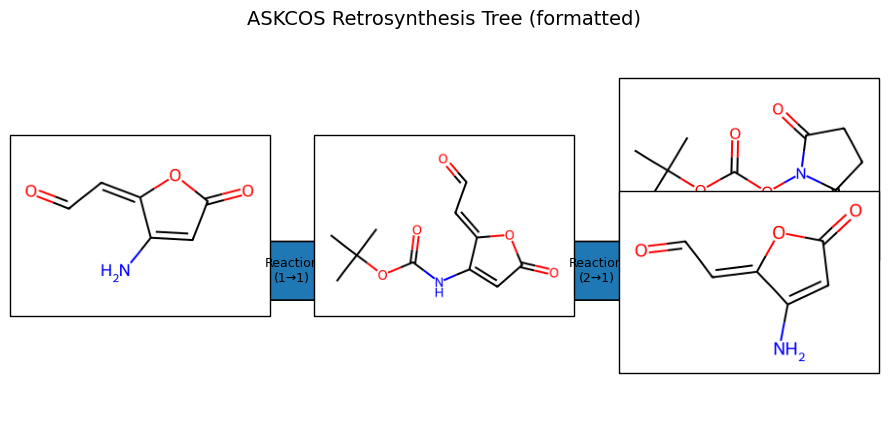

('/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/ASKCOS/askcos_tree.png',
 '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/ASKCOS/askcos_tree.tiff')

In [8]:
import json
from collections import deque

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from rdkit import Chem
from rdkit.Chem import Draw

jsonPath = dataDir + "ASKCOS/treeResults.json"

with open(jsonPath, "r") as f:
    tree = json.load(f)

# Build directed graph
G = nx.DiGraph()
nodeInfo = {}
for n in tree["nodes"]:
    nodeInfo[n["id"]] = n
    G.add_node(n["id"], **n)
for e in tree["edges"]:
    G.add_edge(e["from"], e["to"], **e)

# Root
rootId = "00000000-0000-0000-0000-000000000000"
if rootId not in G:
    roots = [n for n in G.nodes() if G.in_degree(n) == 0]
    rootId = roots[0] if roots else list(G.nodes())[0]

# Depth (BFS)
depth = {rootId: 0}
q = deque([rootId])
while q:
    u = q.popleft()
    for v in G.successors(u):
        if v not in depth:
            depth[v] = depth[u] + 1
            q.append(v)

# DFS order for stable y assignment
dfsOrder = []
seen = set()
def dfs(u):
    seen.add(u)
    dfsOrder.append(u)
    for v in G.successors(u):
        if v not in seen:
            dfs(v)
dfs(rootId)

# Leaves & y positions
leaves = [n for n in dfsOrder if G.out_degree(n) == 0]
leafY = {n:i for i,n in enumerate(leaves)}

nodeY = {}
# Postorder: place internal nodes at the average of child positions
for u in reversed(dfsOrder):
    if u in leafY:
        nodeY[u] = float(leafY[u])
    else:
        children = [v for v in G.successors(u) if v in depth]
        if not children:
            nodeY[u] = float(len(nodeY))  # fallback
        else:
            nodeY[u] = sum(nodeY[c] for c in children) / len(children)

# Spacing controls (main fix: make layout non-collapsed)
xSpacing = 3.2
ySpacing = 2.2

pos = {}
for n, d in depth.items():
    baseY = -nodeY[n] * ySpacing
    # small offset so reaction nodes do not sit exactly on chemical nodes in linear chains
    if nodeInfo[n].get("type") == "reaction":
        baseY -= 0.4 * ySpacing
    pos[n] = (d * xSpacing, baseY)

maxDepth = max(depth.values()) if depth else 0

# RDKit rendering
def smilesToImage(smiles, size=(260, 180)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Draw.MolToImage(mol, size=size)

# Figure sizing based on depth and number of leaves
nLeaves = max(1, len(leaves))
figW = max(10, (maxDepth + 1) * 2.2)
figH = max(5, nLeaves * 1.7)

fig, ax = plt.subplots(figsize=(figW, figH))

extraArtists = []

# Draw edges
for u, v in G.edges():
    if u not in pos or v not in pos:
        continue
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    # slight x offsets so arrows do not run through the node centers
    arrow = FancyArrowPatch(
        (x1 + 0.55, y1), (x2 - 0.55, y2),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.2,
        zorder=1
    )
    ax.add_patch(arrow)
    extraArtists.append(arrow)

# Draw nodes
for n in dfsOrder:
    if n not in pos:
        continue
    x, y = pos[n]
    nType = nodeInfo[n].get("type", "chemical")
    s = nodeInfo[n].get("smiles", "")

    if nType == "chemical":
        img = smilesToImage(s)
        if img is not None:
            imagebox = OffsetImage(img, zoom=0.70)
            ab = AnnotationBbox(
                imagebox, (x, y),
                frameon=True,
                pad=0.25,
                zorder=3
            )
            ax.add_artist(ab)
            extraArtists.append(ab)
        else:
            t = ax.text(x, y, s, ha="center", va="center", fontsize=8, zorder=3)
            extraArtists.append(t)
    else:
        # Reaction node
        reactants = s.split(">>", 1)[0] if ">>" in s else ""
        nReactants = len([r for r in reactants.split(".") if r.strip()]) if reactants else 0
        label = f"Reaction\n({nReactants}→1)"

        w, h = 1.8, 0.9
        box = FancyBboxPatch(
            (x - w/2, y - h/2), w, h,
            boxstyle="round,pad=0.12,rounding_size=0.12",
            linewidth=1.2,
            zorder=2
        )
        ax.add_patch(box)
        extraArtists.append(box)
        t = ax.text(x, y, label, ha="center", va="center", fontsize=9, zorder=3)
        extraArtists.append(t)

# Set axis limits explicitly (important for AnnotationBbox + tight saving)
xs = [p[0] for p in pos.values()]
ys = [p[1] for p in pos.values()]
xPad = xSpacing * 0.8
yPad = ySpacing * 1.2
ax.set_xlim(min(xs) - xPad, max(xs) + xPad)
ax.set_ylim(min(ys) - yPad, max(ys) + yPad)

ax.set_axis_off()
ax.set_title("ASKCOS Retrosynthesis Tree (formatted)", fontsize=14)

# Force draw before saving (helps tight bbox include artists)
fig.canvas.draw()

pngPath = dataDir + "ASKCOS/askcos_tree.png"
tifPath = dataDir + "ASKCOS/askcos_tree.tiff"
fig.savefig(pngPath, dpi=300, bbox_inches="tight", bbox_extra_artists=extraArtists)

try:
    fig.savefig(tifPath, dpi=300, bbox_inches="tight", bbox_extra_artists=extraArtists)
except Exception:
    from PIL import Image
    Image.open(pngPath).save(tifPath)

plt.show()

(pngPath, tifPath)